# LAB | Imbalanced

**Load the data**

In this challenge, we will be working with Credit Card Fraud dataset.

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv

Metadata

- **distance_from_home:** the distance from home where the transaction happened.
- **distance_from_last_transaction:** the distance from last transaction happened.
- **ratio_to_median_purchase_price:** Ratio of purchased price transaction to median purchase price.
- **repeat_retailer:** Is the transaction happened from same retailer.
- **used_chip:** Is the transaction through chip (credit card).
- **used_pin_number:** Is the transaction happened by using PIN number.
- **online_order:** Is the transaction an online order.
- **fraud:** Is the transaction fraudulent. **0=legit** -  **1=fraud**


In [29]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [30]:
fraud = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
fraud.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**Steps:**

- **1.** What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?
- **2.** Train a LogisticRegression.
- **3.** Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.
- **4.** Run **Oversample** in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model? 
- **5.** Now, run **Undersample** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?
- **6.** Finally, run **SMOTE** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model? 

<Axes: xlabel='fraud'>

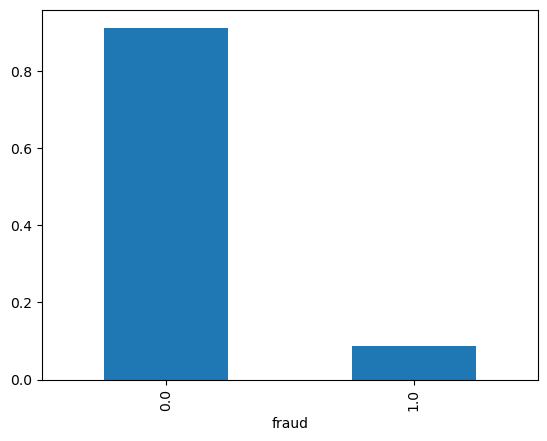

In [31]:
# Distribución

fraud["fraud"].value_counts(normalize=True).plot(kind="bar")

# Sí, está muy desbalanceado.

## Subset y entrenamiento

In [32]:
X = fraud.drop(columns=["fraud"])
y = fraud["fraud"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0, stratify=y
)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


In [35]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=0
)
log_reg.fit(X_train, y_train)
pred_log = log_reg.predict(X_test)

## Evalúa el modelo

In [36]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

print("LOGREG acc:", accuracy_score(y_test, pred_log))
print("LOGREG bal_acc:", balanced_accuracy_score(y_test, pred_log))
print("LOGREG f1_pos:", f1_score(y_test, pred_log, pos_label=1))
print(classification_report(y_test, pred_log, digits=4))

LOGREG acc: 0.95909
LOGREG bal_acc: 0.7979670693788226
LOGREG f1_pos: 0.72031175223901
              precision    recall  f1-score   support

         0.0     0.9631    0.9932    0.9779    182519
         1.0     0.8949    0.6027    0.7203     17481

    accuracy                         0.9591    200000
   macro avg     0.9290    0.7980    0.8491    200000
weighted avg     0.9571    0.9591    0.9554    200000



## OVERSAMPLE

In [37]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=0)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)


In [38]:

log_reg_over = LogisticRegression(
    max_iter=1000,
    random_state=0
)
log_reg_over.fit(X_train_over, y_train_over)
pred_log_over = log_reg_over.predict(X_test)

In [39]:
print("LOGREG acc:", accuracy_score(y_test, pred_log_over))
print("LOGREG bal_acc:", balanced_accuracy_score(y_test, pred_log_over))
print("LOGREG f1_pos:", f1_score(y_test, pred_log_over, pos_label=1))
print(classification_report(y_test, pred_log_over, digits=4))

LOGREG acc: 0.933585
LOGREG bal_acc: 0.9409559828387661
LOGREG f1_pos: 0.7143010775815715
              precision    recall  f1-score   support

         0.0     0.9949    0.9320    0.9624    182519
         1.0     0.5723    0.9499    0.7143     17481

    accuracy                         0.9336    200000
   macro avg     0.7836    0.9410    0.8384    200000
weighted avg     0.9579    0.9336    0.9407    200000



## UNDERSAMPLING

In [40]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=0)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

In [41]:

log_reg_under = LogisticRegression(
    max_iter=1000,
    random_state=0
)
log_reg_under.fit(X_train_under, y_train_under)
pred_log_under = log_reg_under.predict(X_test)

In [42]:
print("LOGREG acc:", accuracy_score(y_test, pred_log_under))
print("LOGREG bal_acc:", balanced_accuracy_score(y_test, pred_log_under))
print("LOGREG f1_pos:", f1_score(y_test, pred_log_under, pos_label=1))
print(classification_report(y_test, pred_log_under, digits=4))

LOGREG acc: 0.93335
LOGREG bal_acc: 0.9409048182455857
LOGREG f1_pos: 0.7136166373050316
              precision    recall  f1-score   support

         0.0     0.9949    0.9317    0.9623    182519
         1.0     0.5714    0.9501    0.7136     17481

    accuracy                         0.9334    200000
   macro avg     0.7832    0.9409    0.8380    200000
weighted avg     0.9579    0.9334    0.9406    200000



## SMOTE

In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [44]:

log_reg_smote = LogisticRegression(
    max_iter=1000,
    random_state=0
)
log_reg_smote.fit(X_train_smote, y_train_smote)
pred_log_smote = log_reg_smote.predict(X_test)

In [45]:
print("LOGREG acc:", accuracy_score(y_test, pred_log_smote))
print("LOGREG bal_acc:", balanced_accuracy_score(y_test, pred_log_smote))
print("LOGREG f1_pos:", f1_score(y_test, pred_log_smote, pos_label=1))
print(classification_report(y_test, pred_log_smote, digits=4))

LOGREG acc: 0.933505
LOGREG bal_acc: 0.9409380148274309
LOGREG f1_pos: 0.7140676399131388
              precision    recall  f1-score   support

         0.0     0.9949    0.9319    0.9624    182519
         1.0     0.5720    0.9499    0.7141     17481

    accuracy                         0.9335    200000
   macro avg     0.7835    0.9409    0.8382    200000
weighted avg     0.9579    0.9335    0.9407    200000



## CONCLUSIONES

- Los resultados de recall de fraude son mucho mejores en los modelos que han sido rebalanceados. Smote es el que mejor se comporta en equilibrio. 